In [1]:
import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
SEED = 2912

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
torch.backends.cudnn.benchmark = True

In [3]:
DATASET_PATH = "../Dataset"
DATASET_NAME = "Mendeley_Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
LR = 3e-4
ACCUM_STEPS = 2
PATIENCE = 15
MIN_DELTA = 0.001

OUTPUT_DIR = f"../Results/{DATASET_NAME}/Model_8"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [5]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 0.9)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
full_dataset = datasets.ImageFolder(f"{DATASET_PATH}/{DATASET_NAME}")

class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(class_names)
print(num_classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
7


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class HybridCACNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # CNN backbone
        self.conv1 = self._block(3, 32)
        self.conv2 = self._block(32, 64)
        self.conv3 = self._block(64, 96)
        self.conv4 = self._block(96, 128)

        # Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=2,
            batch_first=True,
            dropout=0.2
        )

        self.norm1 = nn.LayerNorm(128)

        # Feed Forward
        self.ffn = nn.Sequential(
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128)
        )

        self.norm2 = nn.LayerNorm(128)

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(64, num_classes)
        )

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Flatten to tokens
        x = x.flatten(2).transpose(1, 2)

        # Attention block
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))

        # FFN block
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))

        # Global average pooling over tokens
        x = x.mean(dim=1)

        return self.classifier(x)

In [8]:
model = HybridCACNet(num_classes).to(device)

In [9]:
# Total parameters
total_params = sum(p.numel() for p in model.parameters())

# Trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 327,335
Trainable Parameters: 327,335


In [10]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
HybridCACNet                             [1, 7]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         128
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 96, 28, 28]           --
│    └─Conv2d: 2-9                       [1, 96, 56, 56]           55,392
│    

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

scaler = GradScaler()

In [12]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss/len(loader), acc, all_labels, all_preds

In [13]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_acc = 0
best_weights = copy.deepcopy(model.state_dict())
early_counter = 0

In [14]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        # Apply MixUp
        mixed_images, targets_a, targets_b, lam = mixup_data(
            images,
            labels,
            alpha=0.2
        )

        with autocast(device_type=device.type):
            outputs = model(mixed_images)

            loss = (
                lam * criterion(outputs, targets_a)
                + (1 - lam) * criterion(outputs, targets_b)
            ) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i+1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item()*ACCUM_STEPS

        preds = outputs.argmax(1)

        correct += (
            lam * (preds == targets_a).sum().item()
            + (1 - lam) * (preds == targets_b).sum().item()
        )

        total += labels.size(0)
    
    if len(train_loader) % ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"Early Counter: {early_counter} | Best Val Acc: {best_acc:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print("-"*30)

    if val_acc > best_acc + MIN_DELTA:
        best_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, f"{OUTPUT_DIR}/best_model.pth")
        early_counter = 0
    else:
        early_counter += 1

    if early_counter >= PATIENCE:
        print("Early stopping")
        break

Epoch 1/100
LR: 3.00e-04
Early Counter: 0 | Best Val Acc: 0.0000
Train Acc: 0.3042 | Val Acc: 0.3896
Train Loss: 1.7847 | Val Loss: 1.6666
------------------------------
Epoch 2/100
LR: 3.00e-04
Early Counter: 0 | Best Val Acc: 0.3896
Train Acc: 0.4094 | Val Acc: 0.4594
Train Loss: 1.6340 | Val Loss: 1.5383
------------------------------
Epoch 3/100
LR: 3.00e-04
Early Counter: 0 | Best Val Acc: 0.4594
Train Acc: 0.4270 | Val Acc: 0.3782
Train Loss: 1.5759 | Val Loss: 1.6644
------------------------------
Epoch 4/100
LR: 3.00e-04
Early Counter: 1 | Best Val Acc: 0.4594
Train Acc: 0.4590 | Val Acc: 0.5633
Train Loss: 1.5268 | Val Loss: 1.4031
------------------------------
Epoch 5/100
LR: 3.00e-04
Early Counter: 0 | Best Val Acc: 0.5633
Train Acc: 0.4623 | Val Acc: 0.5487
Train Loss: 1.5214 | Val Loss: 1.4073
------------------------------
Epoch 6/100
LR: 3.00e-04
Early Counter: 1 | Best Val Acc: 0.5633
Train Acc: 0.4872 | Val Acc: 0.5195
Train Loss: 1.4684 | Val Loss: 1.3865
-----------

In [15]:
model.load_state_dict(best_weights)

val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader)

In [16]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.6915584415584416, 'precision': 0.6905170048236429, 'recall': 0.6915584415584416, 'f1': 0.6870875441737466, 'mcc': 0.6232442599100024, 'balanced_accuracy': 0.6554907439269838}
              precision    recall  f1-score   support

    Bacteria       0.86      0.92      0.89       126
       Fungi       0.63      0.69      0.66       139
     Healthy       0.59      0.31      0.41        42
    Nematode       0.57      0.73      0.64        11
        Pest       0.53      0.54      0.54       112
 Phytopthora       0.65      0.65      0.65        71
       Virus       0.81      0.75      0.78       115

    accuracy                           0.69       616
   macro avg       0.66      0.66      0.65       616
weighted avg       0.69      0.69      0.69       616



In [17]:
pd.DataFrame(history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json","w") as f:
    json.dump(results,f,indent=4)

with open(f"{OUTPUT_DIR}/report.txt","w") as f:
    f.write(report)

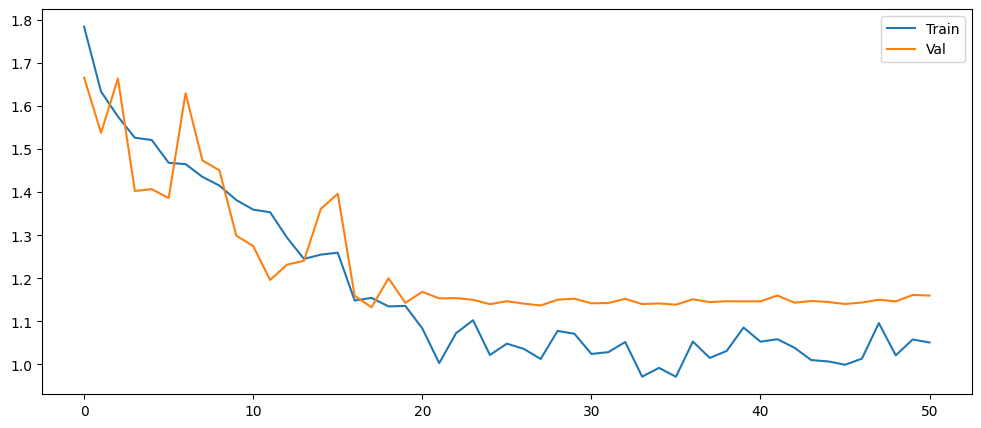

In [18]:
plt.figure(figsize=(12,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png")
plt.show()

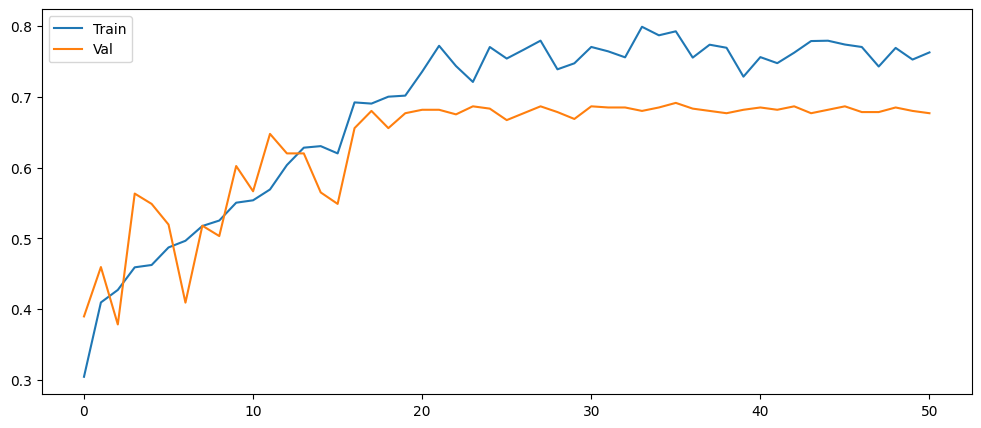

In [19]:
plt.figure(figsize=(12,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png")
plt.show()

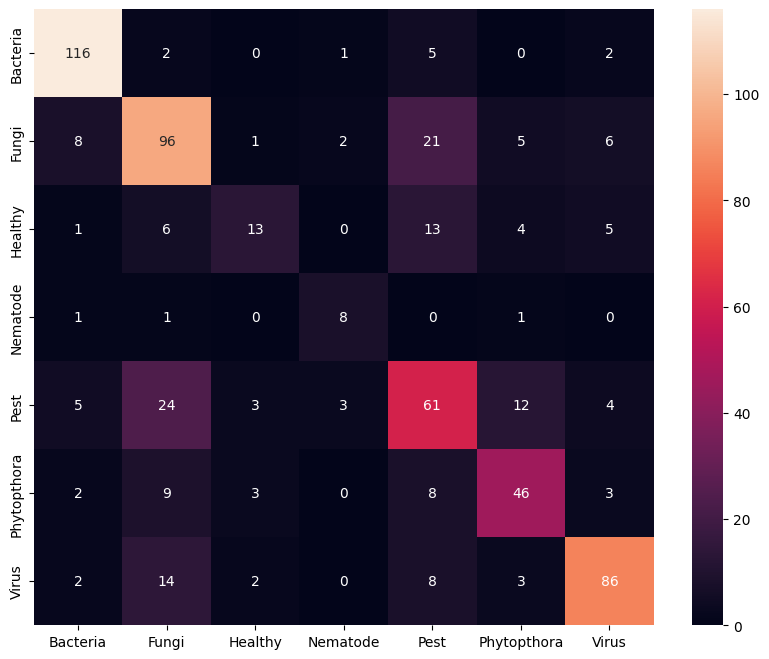

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()